In [1]:
!pip install pandas
!pip install imbalanced-learn
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score, f1_score
from imblearn.over_sampling import RandomOverSampler

#loads all 4 files 
#train data 
X_train    = pd.read_csv("14-18kmerdata.txt", sep="\t")
meta_train = pd.read_csv("14-18metadata", sep=",")
#test data 
X_test     = pd.read_csv("19kmerdata.txt", sep="\t")
meta_test  = pd.read_csv("19metadata", sep=",")

# ── CHECK FOR SPELLING MISTAKES ───────────────────────────
#print("Training countries:")
#print(sorted(meta_train['Country'].unique()))

#print("\nTesting countries:")
#print(sorted(meta_test['Country'].unique()))

# Find values that appear in test but not in train (potential mismatches)
#train_countries = set(meta_train['Country'].unique())
#test_countries  = set(meta_test['Country'].unique())

#print("\nIn test but not in train:")
#print(test_countries - train_countries)

#print("\nIn train but not in test:")
#print(train_countries - test_countries)

In [3]:
#Transpose for scikit learn 
X_train = X_train.T
X_test  = X_test.T
#now the rows are samples and columns are features 

#Cleaning 
X_train.index    = X_train.index.astype(str).str.strip() #comverts rows into string and removes white spaces
X_test.index     = X_test.index.astype(str).str.strip()
meta_train       = meta_train.set_index('Accession')  #Accession is the index of the data so samples can be looked up by ID
meta_test        = meta_test.set_index('Accession')
meta_train.index = meta_train.index.astype(str).str.strip()
meta_test.index  = meta_test.index.astype(str).str.strip()

print(meta_train['Country'].value_counts())
print(meta_test['Country'].value_counts())

#Matching samples 
train_common = X_train.index.intersection(meta_train.index)  #matches samples between k-mer data and metadata 
X_train    = X_train.loc[train_common]  #filters X_train 
meta_train = meta_train.loc[train_common]  #filters meta_train 

test_common = X_test.index.intersection(meta_test.index)
X_test    = X_test.loc[test_common]
meta_test = meta_test.loc[test_common]

print(f"Training samples matching: {len(train_common)}")
print(f"Testing samples matching: {len(test_common)}")

#test data needs to match training data. 
X_test_aligned = X_test[X_train.columns]


#fix typos and inconsistencies 
for meta in [meta_train, meta_test]:
    meta['Country'] = meta['Country'].str.strip()
    meta['Region']  = meta['Region'].str.strip()

    country_corrections = {
    'N':             'UK',
    'Wales':         'UK',
    'Holland':       'Netherlands',
    'Portgual':      'Portugal',
    'Philipines':    'Philippines',
    'Saudia Arabia': 'Saudi Arabia',
    }
    meta['Country'] = meta['Country'].replace(country_corrections)   
    
    
print(meta_train['Country'].value_counts())
print(meta_test['Country'].value_counts())
    
    
#extract labels 
y_train_country = meta_train['Country'].str.strip()
y_test_country  = meta_test['Country'].str.strip()

y_train_region = meta_train['Region'].str.strip()
y_test_region  = meta_test['Region'].str.strip()



print("Setup complete!")
print(y_train_country.value_counts())
print(y_train_region.value_counts())

Country
N                                1905
Spain                             101
Turkey                             84
Morocco                            34
Egypt                              23
                                 ... 
Madagascar                          1
Nigeria                             1
St Vincent and the Grenadines       1
Iran                                1
Jordan                              1
Name: count, Length: 73, dtype: int64
Country
N              267
Turkey          37
Spain           11
Egypt           11
Cyprus           9
Portugal         9
Greece           5
Tunisia          5
Poland           4
Holland          3
UAE              3
Indonesia        3
Malta            3
Israel           3
Morocco          3
Antigua          3
France           3
Australia        2
Mexico           2
India            2
Bulgaria         2
Italy            2
Croatia          2
China            2
Belgium          2
Denmark          2
Switzerland      1
Ireland        

In [4]:
#print(y_train_country.value_counts().to_string())
#to see the distribution of samples for each class in training country (70 classes)

Country
UK                               1907
Spain                             101
Turkey                             84
Morocco                            34
Egypt                              23
Cyprus                             21
Italy                              20
Greece                             20
France                             19
Portugal                           17
India                              13
Mexico                             12
Ireland                            11
Indonesia                          11
USA                                10
Cape Verde                          9
Israel                              9
Pakistan                            9
Poland                              9
Kenya                               9
UAE                                 9
Cuba                                6
Tanzania                            6
Malta                               5
Algeria                             4
Hungary                             4
Bulg

In [5]:
#Dataset breakdown 

dataset_summary = pd.DataFrame({
    'Dataset': [
        'Country training', 
        'Country testing', 
        'Region training', 
        'Region testing'
    ],
    'Samples': [
        X_train.shape[0],
        X_test_aligned.shape[0],
        X_train.shape[0],
        X_test_aligned.shape[0]
    ],
    'Kmer_features': [
        X_train.shape[1],
        X_test_aligned.shape[1],
        X_train.shape[1],
        X_test_aligned.shape[1]
    ],
    'Classes': [
        y_train_country.nunique(),
        y_test_country.nunique(),
        y_train_region.nunique(),
        y_test_region.nunique()
    ],
    'Class_type': [
        'Country',
        'Country',
        'Region',
        'Region'
    ]
})

display(dataset_summary)
dataset_summary.to_csv("outputs/tables/dataset_summary.csv", index=False)




,Dataset,Samples,Kmer_features,Classes,Class_type
0,Country training,2459,49999,70,Country
1,Country testing,415,49999,41,Country
2,Region training,2459,49999,12,Region
3,Region testing,415,49999,11,Region


In [6]:
#Experiment 1 Baseline models

from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score #to evaluate performance 
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import precision_score, recall_score

results_exp1 = [] #empty list to store results 

#Original country 
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=2)
rf.fit(X_train, y_train_country)  #trains on X_train using labels from y_train_country 
y_pred = rf.predict(X_test_aligned)
y_pred_exp1_country = y_pred
results_exp1.append({
    'Model': 'Original country',
    'Accuracy': accuracy_score(y_test_country, y_pred),
    'Balanced_accuracy': balanced_accuracy_score(y_test_country, y_pred),
    'Macro_F1_score': f1_score(y_test_country, y_pred, average='macro', zero_division=0),
    'Weighted_F1_score': f1_score(y_test_country, y_pred, average='weighted', zero_division=0),
    'MCC': matthews_corrcoef(y_test_country, y_pred),
    'Macro_Precision': precision_score(y_test_country, y_pred, average='macro', zero_division=0),
    'Macro_Recall': recall_score(y_test_country, y_pred, average='macro', zero_division=0)
})

#Original region 
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=2)
rf.fit(X_train, y_train_region)
y_pred = rf.predict(X_test_aligned)
y_pred_exp1_region = y_pred
results_exp1.append({
    'Model': 'Original region',
    'Accuracy': accuracy_score(y_test_region, y_pred),
    'Balanced_accuracy': balanced_accuracy_score(y_test_region, y_pred),
    'Macro_F1_score': f1_score(y_test_region, y_pred, average='macro', zero_division=0),
    'Weighted_F1_score': f1_score(y_test_region, y_pred, average='weighted', zero_division=0),
    'MCC': matthews_corrcoef(y_test_region, y_pred),
    'Macro_Precision': precision_score(y_test_region, y_pred, average='macro', zero_division=0),
    'Macro_Recall': recall_score(y_test_region, y_pred, average='macro', zero_division=0)
})

results_exp1_df = pd.DataFrame(results_exp1) #converts results into table 
display(results_exp1_df)
results_exp1_df.to_csv("outputs/tables/results_experiment1.csv", index=False)

,Model,Accuracy,Balanced_accuracy,Macro_F1_score,Weighted_F1_score,MCC,Macro_Precision,Macro_Recall
0,Original country,0.691566,0.089003,0.091605,0.613015,0.346482,0.119183,0.089003
1,Original region,0.698795,0.269470,0.299262,0.644444,0.366659,0.379169,0.269470


In [7]:
#Experiment 2 

# class weights 
results_exp2 = []

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=2)
rf.fit(X_train, y_train_country)
y_pred = rf.predict(X_test_aligned)
results_exp2.append({
    'Model': 'Class weight country',
    'Accuracy': accuracy_score(y_test_country, y_pred),
    'Balanced_accuracy': balanced_accuracy_score(y_test_country, y_pred),
    'Macro_F1_score': f1_score(y_test_country, y_pred, average='macro', zero_division=0),
    'Weighted_F1_score': f1_score(y_test_country, y_pred, average='weighted', zero_division=0),
    'MCC': matthews_corrcoef(y_test_country, y_pred),
    'Macro_Precision': precision_score(y_test_country, y_pred, average='macro', zero_division=0),
    'Macro_Recall': recall_score(y_test_country, y_pred, average='macro', zero_division=0)
})


rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=2)
rf.fit(X_train, y_train_region)
y_pred = rf.predict(X_test_aligned)
results_exp2.append({
    'Model': 'Class weight region',
    'Accuracy': accuracy_score(y_test_region, y_pred),
    'Balanced_accuracy': balanced_accuracy_score(y_test_region, y_pred),
    'Macro_F1_score': f1_score(y_test_region, y_pred, average='macro', zero_division=0),
    'Weighted_F1_score': f1_score(y_test_region, y_pred, average='weighted', zero_division=0),
    'MCC': matthews_corrcoef(y_test_region, y_pred),
    'Macro_Precision': precision_score(y_test_region, y_pred, average='macro', zero_division=0),
    'Macro_Recall': recall_score(y_test_region, y_pred, average='macro', zero_division=0)

})

#oversampling 
#1.country
max_samples = 100
sampling_dict_country = {
    country: max_samples
    for country, count in y_train_country.value_counts().items()
    if count < max_samples
}
ros = RandomOverSampler(sampling_strategy=sampling_dict_country, random_state=42)
X_res_country, y_res_country = ros.fit_resample(X_train, y_train_country)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=2)
rf.fit(X_res_country, y_res_country)
y_pred = rf.predict(X_test_aligned)
y_pred_exp2_country = y_pred
results_exp2.append({
    'Model': 'Oversampled country',
    'Accuracy': accuracy_score(y_test_country, y_pred),
    'Balanced_accuracy': balanced_accuracy_score(y_test_country, y_pred),
    'Macro_F1_score': f1_score(y_test_country, y_pred, average='macro', zero_division=0),
    'Weighted_F1_score': f1_score(y_test_country, y_pred, average='weighted', zero_division=0),
    'MCC': matthews_corrcoef(y_test_country, y_pred),
    'Macro_Precision': precision_score(y_test_country, y_pred, average='macro', zero_division=0),
    'Macro_Recall': recall_score(y_test_country, y_pred, average='macro', zero_division=0)
})


#2.region 

sampling_dict_region = {
    region: max_samples
    for region, count in y_train_region.value_counts().items()
    if count < max_samples
}
ros = RandomOverSampler(sampling_strategy=sampling_dict_region, random_state=42)
X_res_region, y_res_region = ros.fit_resample(X_train, y_train_region)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=2)
rf.fit(X_res_region, y_res_region)
y_pred = rf.predict(X_test_aligned)
y_pred_exp2_region = y_pred 
results_exp2.append({
    'Model': 'Oversampled region',
    'Accuracy': accuracy_score(y_test_region, y_pred),
    'Balanced_accuracy': balanced_accuracy_score(y_test_region, y_pred),
    'Macro_F1_score': f1_score(y_test_region, y_pred, average='macro', zero_division=0),
    'Weighted_F1_score': f1_score(y_test_region, y_pred, average='weighted', zero_division=0),
    'MCC': matthews_corrcoef(y_test_region, y_pred),
    'Macro_Precision': precision_score(y_test_region, y_pred, average='macro', zero_division=0),
    'Macro_Recall': recall_score(y_test_region, y_pred, average='macro', zero_division=0)
})

results_exp2_df = pd.DataFrame(results_exp2)
display(results_exp2_df)
results_exp2_df.to_csv("outputs/tables/results_experiment2.csv", index=False)





/home/jovyan/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,Model,Accuracy,Balanced_accuracy,Macro_F1_score,Weighted_F1_score,MCC,Macro_Precision,Macro_Recall
0,Class weight country,0.686747,0.065230,0.070095,0.597844,0.315860,0.087009,0.065230
1,Class weight region,0.720482,0.270901,0.309279,0.659567,0.412005,0.457937,0.270901
2,Oversampled country,0.696386,0.126137,0.123569,0.631673,0.381117,0.154030,0.123134
3,Oversampled region,0.698795,0.278313,0.308671,0.651370,0.377442,0.374390,0.278313


In [8]:
# Experiment 3

#using oversampled to balance 

import gc
import os
os.makedirs("outputs/tables", exist_ok=True)


for k in [1000, 2000, 5000, 10000, 20000, 30000]:
    results_exp3 = []

    #Country-oversampling + feature selection
    selector_country = SelectKBest(chi2, k=k)
    X_res_sel = selector_country.fit_transform(X_res_country, y_res_country)
    X_test_sel = selector_country.transform(X_test_aligned)
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=2)
    rf.fit(X_res_sel, y_res_country)
    y_pred = rf.predict(X_test_sel)
    if k == 30000:                        
        y_pred_exp3_country = y_pred   
    results_exp3.append({
        'Model': f'Oversampled country k={k}',
        'k': k,
        'Accuracy': accuracy_score(y_test_country, y_pred),
        'Balanced_accuracy': balanced_accuracy_score(y_test_country, y_pred),
        'Macro_F1_score': f1_score(y_test_country, y_pred, average='macro', zero_division=0),
        'Weighted_F1_score': f1_score(y_test_country, y_pred, average='weighted', zero_division=0),
        'MCC': matthews_corrcoef(y_test_country, y_pred),
        'Macro_Precision': precision_score(y_test_country, y_pred, average='macro', zero_division=0),
        'Macro_Recall': recall_score(y_test_country, y_pred, average='macro', zero_division=0)
        
    })
    gc.collect()

    #Region-oversampling + feature selection
    selector_region = SelectKBest(chi2, k=k)
    X_res_sel = selector_region.fit_transform(X_res_region, y_res_region)
    X_test_sel = selector_region.transform(X_test_aligned)
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=2)
    rf.fit(X_res_sel, y_res_region)
    y_pred = rf.predict(X_test_sel)
    if k == 30000:
        y_pred_exp3_region = y_pred
    results_exp3.append({
        'Model': f'Oversampled region k={k}',
        'k': k,
        'Accuracy': accuracy_score(y_test_region, y_pred),
        'Balanced_accuracy': balanced_accuracy_score(y_test_region, y_pred),
        'Macro_F1_score': f1_score(y_test_region, y_pred, average='macro', zero_division=0),
        'Weighted_F1_score': f1_score(y_test_region, y_pred, average='weighted', zero_division=0),
        'MCC': matthews_corrcoef(y_test_region, y_pred),
        'Macro_Precision': precision_score(y_test_region, y_pred, average='macro', zero_division=0),
        'Macro_Recall': recall_score(y_test_region, y_pred, average='macro', zero_division=0)
    })
    gc.collect()

    #CSV
    results_exp3_df = pd.DataFrame(results_exp3)
    results_exp3_df.to_csv(f"outputs/tables/results_experiment3_k{k}.csv", index=False)
    print(f"Saved results for k={k}")




/home/jovyan/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Saved results for k=1000


/home/jovyan/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Saved results for k=2000


/home/jovyan/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


...

Saved results for k=10000


/home/jovyan/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Saved results for k=20000


/home/jovyan/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Saved results for k=30000


In [9]:
#Experiment 4 
#using k=30,000
#changing n_trees and max_depth 

#feature selection 
selector_country = SelectKBest(chi2, k=30000)
X_res_sel_country = selector_country.fit_transform(X_res_country, y_res_country)
X_test_sel_country = selector_country.transform(X_test_aligned)

selector_region = SelectKBest(chi2, k=30000)
X_res_sel_region = selector_region.fit_transform(X_res_region, y_res_region)
X_test_sel_region = selector_region.transform(X_test_aligned)

results_exp4 = []
print("Feature selection done, ready to run models")




Feature selection done, ready to run models


In [10]:
#100 trees 
for max_d in [10, 20, 50, None]:

    #country
    rf = RandomForestClassifier(n_estimators=100, max_depth=max_d, min_samples_leaf=2, random_state=42, n_jobs=2)
    rf.fit(X_res_sel_country, y_res_country)
    y_pred = rf.predict(X_test_sel_country)
    if max_d is None:                       
        y_pred_exp4_country = y_pred 
    results_exp4.append({
        'Model': 'Country', 'n_estimators': 100, 'max_depth': max_d,
        'Accuracy': accuracy_score(y_test_country, y_pred),
        'Balanced_accuracy': balanced_accuracy_score(y_test_country, y_pred),
        'Macro_F1_score': f1_score(y_test_country, y_pred, average='macro', zero_division=0),
        'Weighted_F1_score': f1_score(y_test_country, y_pred, average='weighted', zero_division=0),
        'MCC': matthews_corrcoef(y_test_country, y_pred),
        'Macro_Precision': precision_score(y_test_country, y_pred, average='macro', zero_division=0),
        'Macro_Recall': recall_score(y_test_country, y_pred, average='macro', zero_division=0)
    })
    gc.collect()

    #region
    rf = RandomForestClassifier(n_estimators=100, max_depth=max_d, min_samples_leaf=2, random_state=42, n_jobs=2)
    rf.fit(X_res_sel_region, y_res_region)
    y_pred = rf.predict(X_test_sel_region)
    if max_d is None:                       
        y_pred_exp4_region = y_pred
    results_exp4.append({
        'Model': 'Region', 'n_estimators': 100, 'max_depth': max_d,
        'Accuracy': accuracy_score(y_test_region, y_pred),
        'Balanced_accuracy': balanced_accuracy_score(y_test_region, y_pred),
        'Macro_F1_score': f1_score(y_test_region, y_pred, average='macro', zero_division=0),
        'Weighted_F1_score': f1_score(y_test_region, y_pred, average='weighted', zero_division=0),
        'MCC': matthews_corrcoef(y_test_region, y_pred),
        'Macro_Precision': precision_score(y_test_region, y_pred, average='macro', zero_division=0),
        'Macro_Recall': recall_score(y_test_region, y_pred, average='macro', zero_division=0)
    })
    gc.collect()
    print(f"Done: n_estimators=100, max_depth={max_d}")

#save n_estimators=100
pd.DataFrame(results_exp4).to_csv("outputs/tables/results_experiment4_100trees.csv", index=False)
print("Saved 100 trees results")

Done: n_estimators=100, max_depth=10


/home/jovyan/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Done: n_estimators=100, max_depth=20


/home/jovyan/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Done: n_estimators=100, max_depth=50


/home/jovyan/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Done: n_estimators=100, max_depth=None
Saved 100 trees results


In [11]:
for max_d in [10, 20, 50, None]:

    #country
    rf = RandomForestClassifier(n_estimators=500, max_depth=max_d, min_samples_leaf=2, random_state=42, n_jobs=2)
    rf.fit(X_res_sel_country, y_res_country)
    y_pred = rf.predict(X_test_sel_country)
    results_exp4.append({
        'Model': 'Country', 'n_estimators': 500, 'max_depth': max_d,
        'Accuracy': accuracy_score(y_test_country, y_pred),
        'Balanced_accuracy': balanced_accuracy_score(y_test_country, y_pred),
        'Macro_F1_score': f1_score(y_test_country, y_pred, average='macro', zero_division=0),
        'Weighted_F1_score': f1_score(y_test_country, y_pred, average='weighted', zero_division=0),
        'MCC': matthews_corrcoef(y_test_country, y_pred),
        'Macro_Precision': precision_score(y_test_country, y_pred, average='macro', zero_division=0),
        'Macro_Recall': recall_score(y_test_country, y_pred, average='macro', zero_division=0)
    })
    gc.collect()

    #region
    rf = RandomForestClassifier(n_estimators=500, max_depth=max_d, min_samples_leaf=2, random_state=42, n_jobs=2)
    rf.fit(X_res_sel_region, y_res_region)
    y_pred = rf.predict(X_test_sel_region)
    results_exp4.append({
        'Model': 'Region', 'n_estimators': 500, 'max_depth': max_d,
        'Accuracy': accuracy_score(y_test_region, y_pred),
        'Balanced_accuracy': balanced_accuracy_score(y_test_region, y_pred),
        'Macro_F1_score': f1_score(y_test_region, y_pred, average='macro', zero_division=0),
        'Weighted_F1_score': f1_score(y_test_region, y_pred, average='weighted', zero_division=0),
        'MCC': matthews_corrcoef(y_test_region, y_pred),
        'Macro_Precision': precision_score(y_test_region, y_pred, average='macro', zero_division=0),
        'Macro_Recall': recall_score(y_test_region, y_pred, average='macro', zero_division=0)
    })
    gc.collect()
    print(f"Done: n_estimators=500, max_depth={max_d}")

#save n_estimators=500
pd.DataFrame(results_exp4).to_csv("outputs/tables/results_experiment4_500trees.csv", index=False)
print("Saved 500 trees results")

Done: n_estimators=500, max_depth=10


/home/jovyan/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Done: n_estimators=500, max_depth=20


/home/jovyan/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Done: n_estimators=500, max_depth=50


/home/jovyan/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Done: n_estimators=500, max_depth=None
Saved 500 trees results


In [12]:
for max_d in [10, 20, 50, None]:

    #country
    rf = RandomForestClassifier(n_estimators=1000, max_depth=max_d, min_samples_leaf=2, random_state=42, n_jobs=2)
    rf.fit(X_res_sel_country, y_res_country)
    y_pred = rf.predict(X_test_sel_country)
    results_exp4.append({
        'Model': 'Country', 'n_estimators': 1000, 'max_depth': max_d,
        'Accuracy': accuracy_score(y_test_country, y_pred),
        'Balanced_accuracy': balanced_accuracy_score(y_test_country, y_pred),
        'Macro_F1_score': f1_score(y_test_country, y_pred, average='macro', zero_division=0),
        'Weighted_F1_score': f1_score(y_test_country, y_pred, average='weighted', zero_division=0),
        'MCC': matthews_corrcoef(y_test_country, y_pred),
        'Macro_Precision': precision_score(y_test_country, y_pred, average='macro', zero_division=0),
        'Macro_Recall': recall_score(y_test_country, y_pred, average='macro', zero_division=0)
    })
    gc.collect()

    #region
    rf = RandomForestClassifier(n_estimators=1000, max_depth=max_d, min_samples_leaf=2, random_state=42, n_jobs=2)
    rf.fit(X_res_sel_region, y_res_region)
    y_pred = rf.predict(X_test_sel_region)
    results_exp4.append({
        'Model': 'Region', 'n_estimators': 1000, 'max_depth': max_d,
        'Accuracy': accuracy_score(y_test_region, y_pred),
        'Balanced_accuracy': balanced_accuracy_score(y_test_region, y_pred),
        'Macro_F1_score': f1_score(y_test_region, y_pred, average='macro', zero_division=0),
        'Weighted_F1_score': f1_score(y_test_region, y_pred, average='weighted', zero_division=0),
        'MCC': matthews_corrcoef(y_test_region, y_pred),
        'Macro_Precision': precision_score(y_test_region, y_pred, average='macro', zero_division=0),
        'Macro_Recall': recall_score(y_test_region, y_pred, average='macro', zero_division=0)
    })
    gc.collect()
    print(f"Done: n_estimators=1000, max_depth={max_d}")

#save final combined results
results_exp4_df = pd.DataFrame(results_exp4)
display(results_exp4_df)
results_exp4_df.to_csv("outputs/tables/results_experiment4_final.csv", index=False)
print("Saved final experiment 4 results")

Done: n_estimators=1000, max_depth=10


/home/jovyan/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Done: n_estimators=1000, max_depth=20


/home/jovyan/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Done: n_estimators=1000, max_depth=50


/home/jovyan/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Done: n_estimators=1000, max_depth=None


,Model,n_estimators,max_depth,Accuracy,Balanced_accuracy,Macro_F1_score,Weighted_F1_score,MCC,Macro_Precision,Macro_Recall
0,Country,100,10.0,0.636145,0.032155,0.028762,0.504246,0.024061,0.027917,0.032155
1,Region,100,10.0,0.703614,0.236662,0.270893,0.627606,0.357548,0.382939,0.236662
2,Country,100,20.0,0.674699,0.074289,0.068799,0.579465,0.271259,0.073524,0.069224
3,Region,100,20.0,0.691566,0.253789,0.278802,0.625844,0.335535,0.358375,0.253789
4,Country,100,50.0,0.689157,0.116036,0.109785,0.609350,0.333622,0.123985,0.110639
5,Region,100,50.0,0.701205,0.267352,0.292648,0.639195,0.363123,0.360364,0.267352
6,Country,100,NaN,0.689157,0.122948,0.120619,0.616606,0.339765,0.143465,0.117230
7,Region,100,NaN,0.708434,0.271733,0.299740,0.647073,0.382844,0.370370,0.271733
8,Country,500,10.0,0.640964,0.032338,0.028850,0.506567,0.045037,0.027960,0.032338
9,Region,500,10.0,0.701205,0.234596,0.265648,0.622605,0.350994,0.382085,0.234596


Saved final experiment 4 results


In [13]:
#Experiment 5 Hierarchical Model

import numpy as np

#Train region model using best settings from Experiment 4
rf_region = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42, n_jobs=2)
rf_region.fit(X_res_sel_region, y_res_region)

#predicting on country data
region_pred_train = rf_region.predict(X_res_sel_country)  #for the samples in the country data, which region does it belong to?
region_pred_test  = rf_region.predict(X_test_sel_country)

#region predictions are converted into numbers for rf
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
region_pred_train_enc = le.fit_transform(region_pred_train).reshape(-1, 1)
region_pred_test_enc  = le.transform(region_pred_test).reshape(-1, 1)

#region predictions are added an extra column feature to country data
X_country_aug_train = np.column_stack((X_res_sel_country, region_pred_train_enc))
X_country_aug_test  = np.column_stack((X_test_sel_country, region_pred_test_enc))

#now we have 30,001 selected features (added region hint)

#train new country model with hierarchical info
rf_country_hier = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42, n_jobs=2)
rf_country_hier.fit(X_country_aug_train, y_res_country)
y_pred_country_hier = rf_country_hier.predict(X_country_aug_test)
y_pred_exp5_country = y_pred_country_hier

#evaluate
results_exp5 = [{
    'Model': 'Hierarchical Country (Region-informed)',
    'Accuracy': accuracy_score(y_test_country, y_pred_country_hier),
    'Balanced_accuracy': balanced_accuracy_score(y_test_country, y_pred_country_hier),
    'Macro_F1_score': f1_score(y_test_country, y_pred_country_hier, average='macro', zero_division=0),
    'Weighted_F1_score': f1_score(y_test_country, y_pred_country_hier, average='weighted', zero_division=0),
    'MCC': matthews_corrcoef(y_test_country, y_pred_country_hier),
    'Macro_Precision': precision_score(y_test_country, y_pred, average='macro', zero_division=0),
    'Macro_Recall': recall_score(y_test_country, y_pred, average='macro', zero_division=0)
}]

results_exp5_df = pd.DataFrame(results_exp5)
display(results_exp5_df)
results_exp5_df.to_csv("outputs/tables/results_experiment5_hierarchical.csv", index=False)







/home/jovyan/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,Model,Accuracy,Balanced_accuracy,Macro_F1_score,Weighted_F1_score,MCC,Macro_Precision,Macro_Recall
0,Hierarchical Country (Region-informed),0.691566,0.123495,0.125361,0.622039,0.343885,0.015137,0.019842


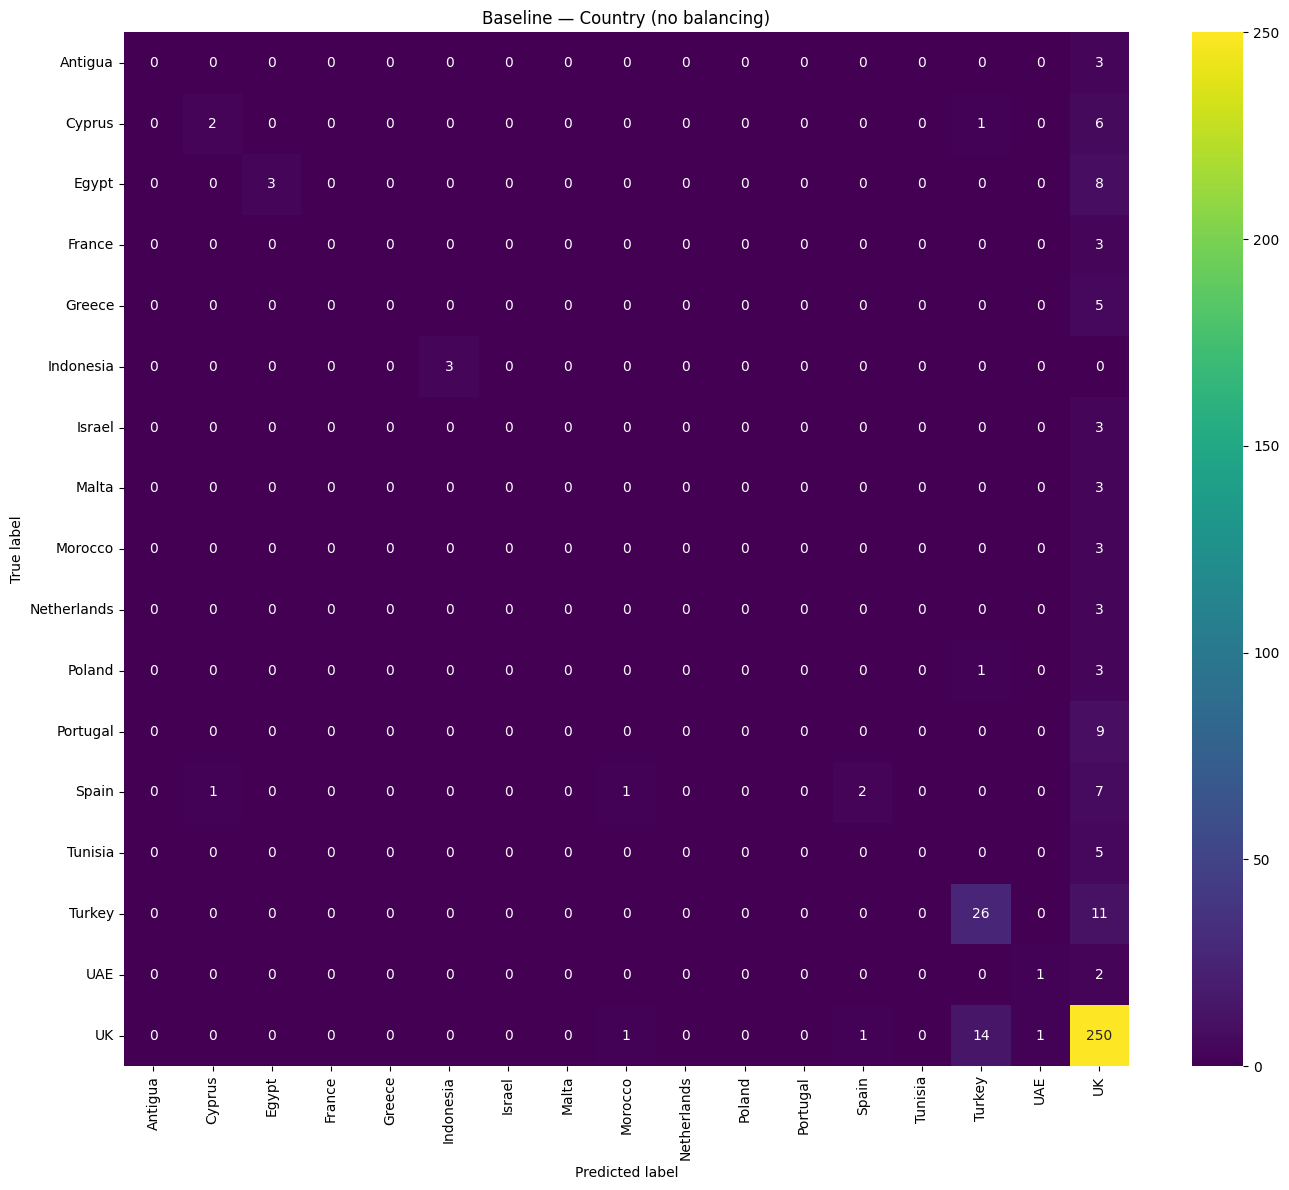

Saved: confusion_matrix_baseline_country.png


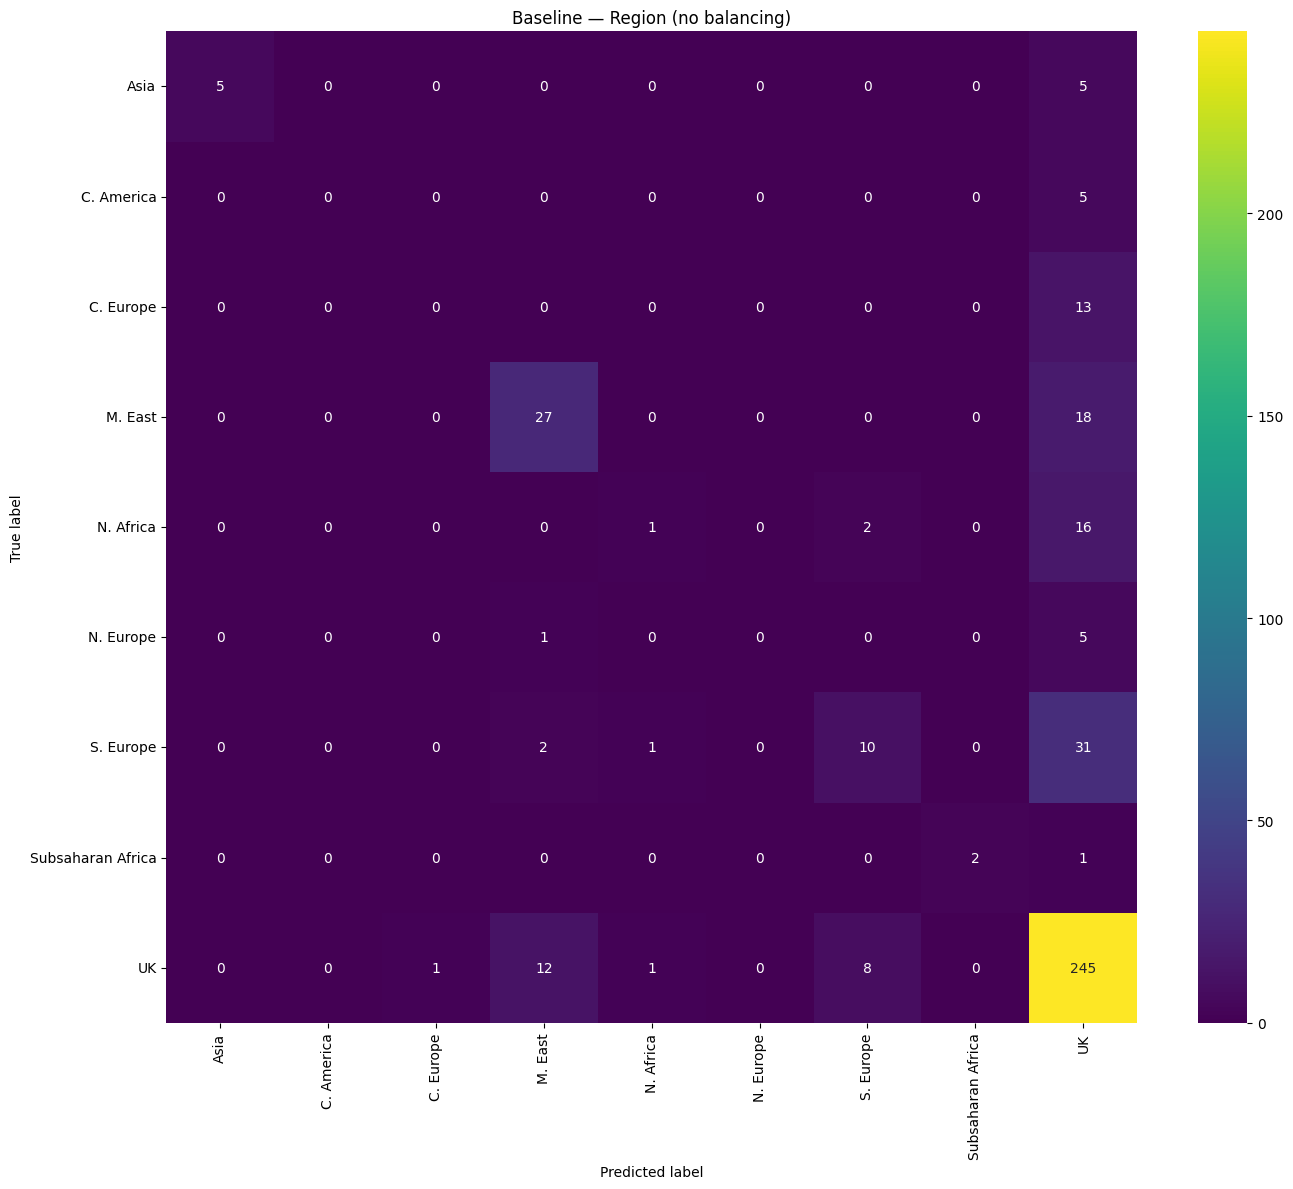

Saved: confusion_matrix_baseline_region.png


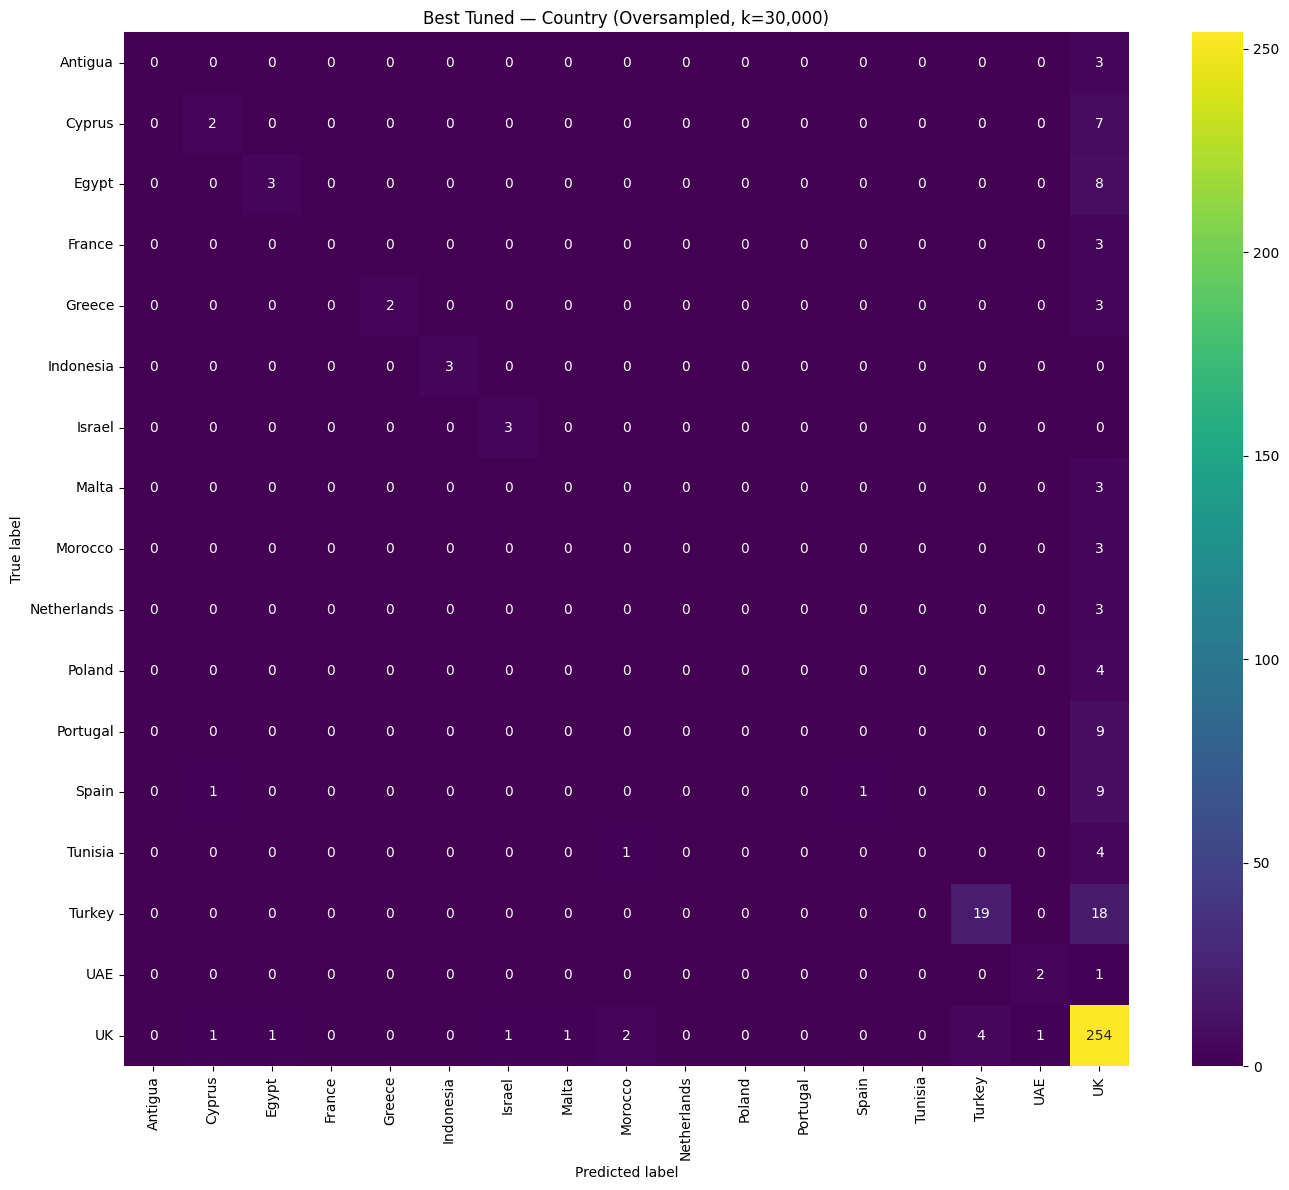

Saved: confusion_matrix_tuned_country.png


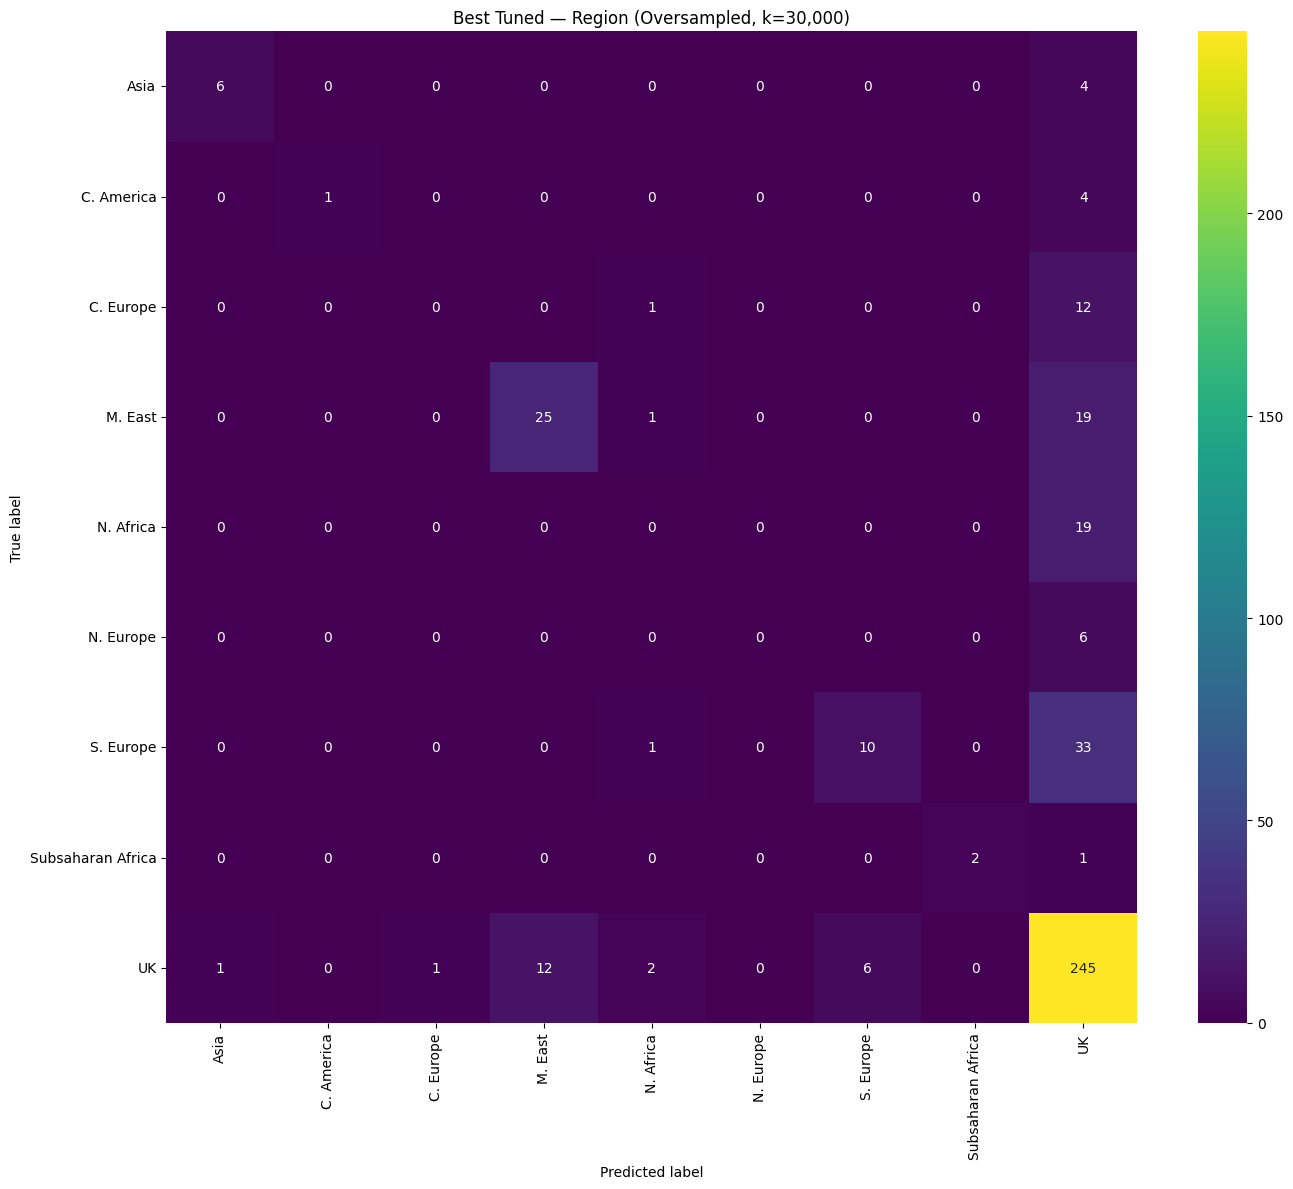

Saved: confusion_matrix_tuned_region.png


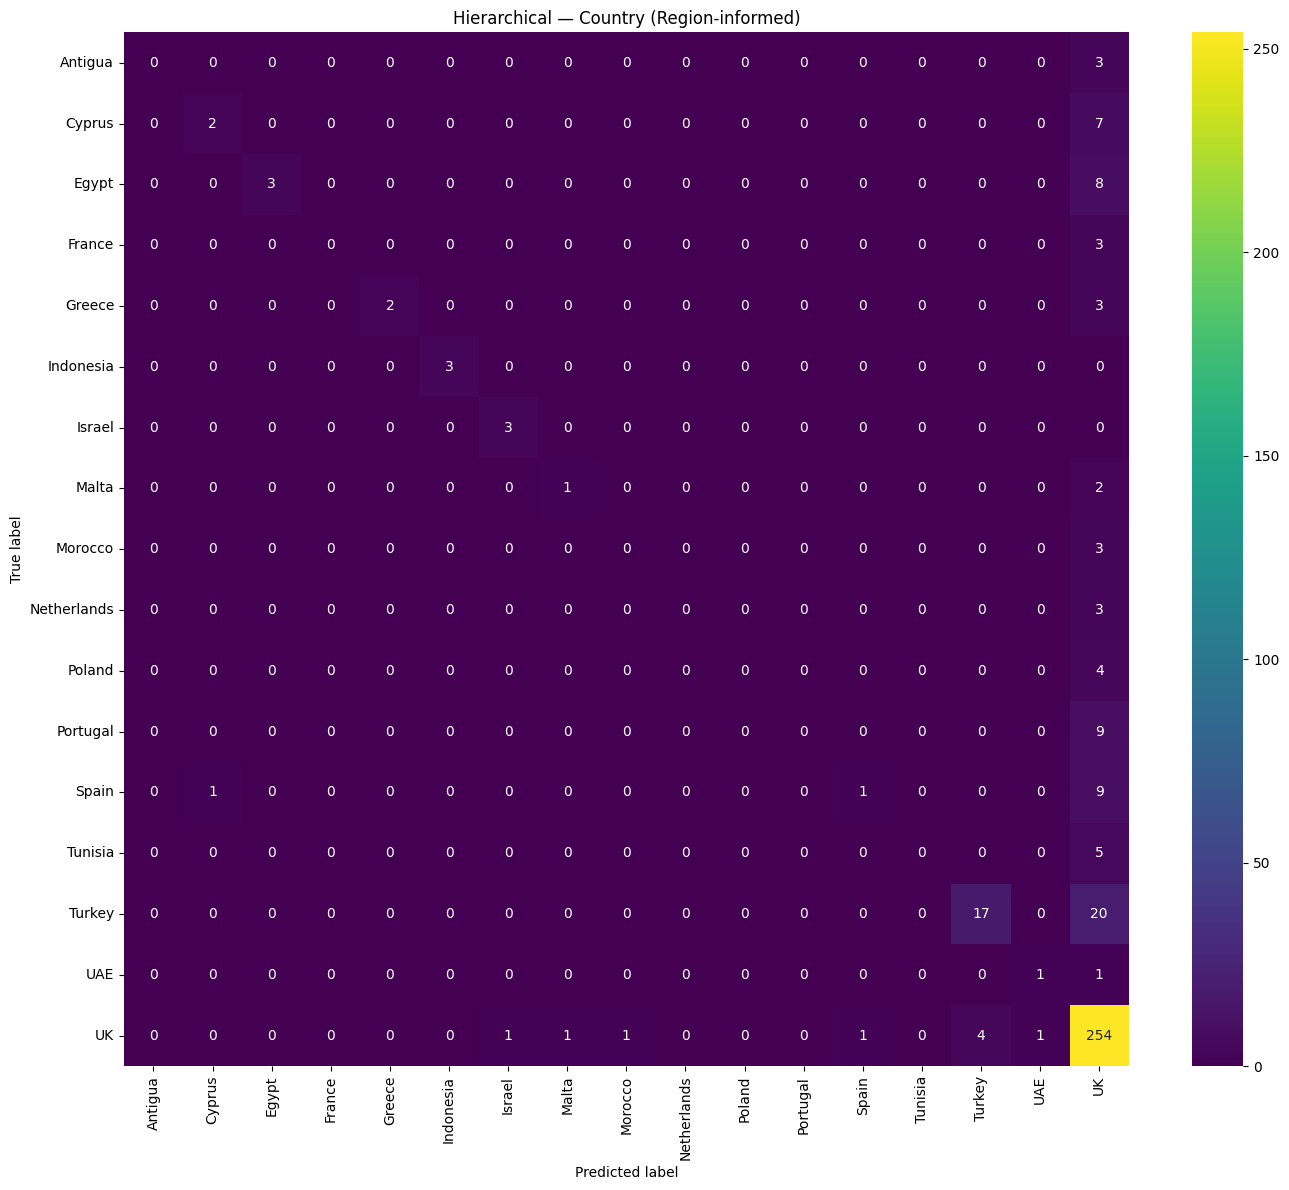

Saved: confusion_matrix_hierarchical_country.png


In [14]:
#confusion matrices 

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os
os.makedirs("outputs/figures", exist_ok=True)

def plot_confusion_matrix(y_true, y_pred, title, filename, min_samples=3):
    counts = y_true.value_counts()
    common_labels = counts[counts >= min_samples].index.tolist()
    mask = y_true.isin(common_labels)
    y_true_filtered = y_true[mask]
    y_pred_filtered = pd.Series(y_pred, index=y_true.index)[mask]
    y_pred_filtered = y_pred_filtered.apply(lambda x: x if x in common_labels else 'Other')
    labels = sorted(common_labels)
    cm = confusion_matrix(y_true_filtered, y_pred_filtered, labels=labels)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.title(title)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f"outputs/figures/{filename}.png")
    plt.show()
    print(f"Saved: {filename}.png")

#Baseline country 
plot_confusion_matrix(
    y_test_country,
    y_pred_exp1_country,
    title='Baseline — Country (no balancing)',
    filename='confusion_matrix_baseline_country'
)

#Baseline region 
plot_confusion_matrix(
    y_test_region,
    y_pred_exp1_region,
    title='Baseline — Region (no balancing)',
    filename='confusion_matrix_baseline_region'
)

#Tuned best performing model country 
plot_confusion_matrix(
    y_test_country,
    y_pred_exp3_country,
    title='Best Tuned — Country (Oversampled, k=30,000)',
    filename='confusion_matrix_tuned_country'
)

#Tuned best performing model region 
plot_confusion_matrix(
    y_test_region,
    y_pred_exp3_region,
    title='Best Tuned — Region (Oversampled, k=30,000)',
    filename='confusion_matrix_tuned_region'
)

#Hierarchical country model 
plot_confusion_matrix(
    y_test_country,
    y_pred_exp5_country,
    title='Hierarchical — Country (Region-informed)',
    filename='confusion_matrix_hierarchical_country'
)